In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [16]:
df = pd.read_csv("insurance_fraud_data.csv")

print(df.head())
print(df.shape)

   claim_number  age_of_driver gender marital_status  safety_rating  \
0        414724             39      M              1             73   
1        269568             33      M              1             72   
2        974592             31      M              1             76   
3        995328             53      F              1             93   
4       1140480             41      M              1             87   

   annual_income  high_education  address_change property_status  zip_code  \
0        58612.8               1               0             Own     50048   
1        35936.0               0               1             Own     50006   
2        84940.8               1               1             Own     15021   
3        73526.4               0               1             Own     85027   
4        59403.2               1               0             Own     80046   

   ... vehicle_category vehicle_price vehicle_color  total_claim injury_claim  \
0  ...            Large

In [17]:
# Fill missing values
mode = df["fraud reported"].mode()[0]
df["fraud reported"] = df["fraud reported"].fillna(mode)

# Remove duplicates
df = df.drop_duplicates()

# Convert date
df["claim_date"] = pd.to_datetime(df["claim_date"], format="mixed", errors="coerce")

# Remove outliers from annual_income
Q1 = df["annual_income"].quantile(0.25)
Q3 = df["annual_income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["annual_income"] >= lower) &
        (df["annual_income"] <= upper)]

print(df.shape)

(10088, 29)


In [31]:
X = df[['age_of_driver',
        'annual_income',
        'vehicle_price',
        'policy deductible',
        'annual premium',
        'form defects']]

y = df['total_claim']

In [32]:
#Split Dataset(Training 80% and testing 20%)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Samples:", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples: (8070, 6)
Testing Samples : (2018, 6)


In [33]:
#Train Linear Regression Model

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Coefficients:")
print(model.coef_)

print("\nIntercept:")
print(model.intercept_)

Coefficients:
[-2.83674773e+01  2.04147920e-02  2.25211821e-04 -8.43575009e-02
 -1.36043714e+00 -9.06875197e+01]

Intercept:
25008.2259062968


In [39]:
#Prediction and Evolution

y_pred = model.predict(X_test)

print("First 10 Predictions")
print(y_pred[:10])

print("\nMean Squared Error")
print(mean_squared_error(y_test, y_pred))

print("\nR2 Score")
print(r2_score(y_test, y_pred))

First 10 Predictions
[22528.17942486 22019.8287148  22460.51380391 23282.09325485
 22449.41784521 22743.32634973 22947.50851253 21498.62084603
 22519.38849417 22490.78527223]

Mean Squared Error
147123166.1064436

R2 Score
-0.002320339672132299


In [42]:
#Feature selling for gradient descent

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X = X_scaled

In [43]:
#Gradient descent from scratch

m = len(y)
n = X.shape[1]

weights = np.zeros(n)
bias = 0

learning_rate = 0.01
epochs = 1000

loss_history = []

for epoch in range(epochs):

    y_pred = np.dot(X, weights) + bias

    error = y_pred - y

    loss = np.mean(error ** 2)
    loss_history.append(loss)

    dw = (2/m) * np.dot(X.T, error)
    db = (2/m) * np.sum(error)

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch} Loss = {loss:.2f}")

print("\nTraining Completed")

Epoch 0 Loss = 670998238.47
Epoch 100 Loss = 159260023.29
Epoch 200 Loss = 150257317.69
Epoch 300 Loss = 150097671.97
Epoch 400 Loss = 150094241.72
Epoch 500 Loss = 150093885.00
Epoch 600 Loss = 150093737.59
Epoch 700 Loss = 150093667.79
Epoch 800 Loss = 150093634.56
Epoch 900 Loss = 150093618.73

Training Completed


In [25]:
#find weight and bias

print("Final Weights")

for i in range(len(weights)):
    print(f"Weight {i+1} = {weights[i]}")

print("\nBias =", bias)

Final Weights
Weight 1 = 0.0
Weight 2 = 0.0
Weight 3 = 0.0
Weight 4 = 0.0
Weight 5 = 0.0
Weight 6 = 0.0
Weight 7 = 0.0

Bias = 0


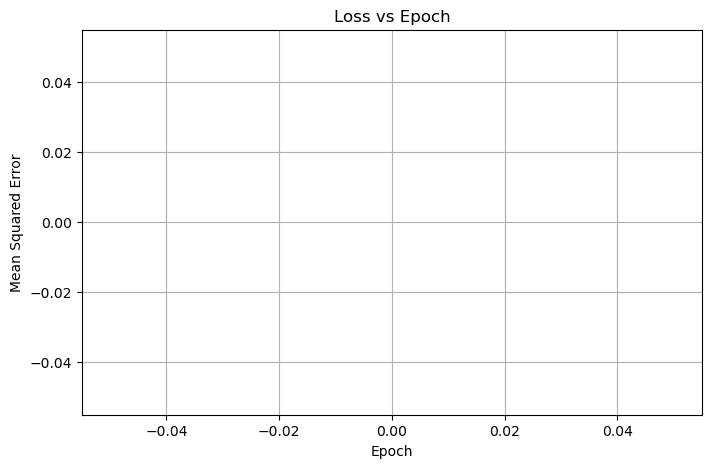

In [26]:
#Loss vs Epoch graph

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.grid(True)

plt.show()

In [44]:
#Compare Sklearn and Gradient Descent

print("========== Comparison ==========")

print("\nSklearn Coefficients")
print(model.coef_)

print("\nGradient Descent Weights")
print(weights)

print("\nSklearn Intercept")
print(model.intercept_)

print("\nGradient Descent Bias")
print(bias)

========== Comparison ==========

Sklearn Coefficients
[-2.83674773e+01  2.04147920e-02  2.25211821e-04 -8.43575009e-02
 -1.36043714e+00 -9.06875197e+01]

Gradient Descent Weights
[-258.15444634   85.9318153    -9.91685176  -91.07601994 -220.5266075
 -133.47108711]

Sklearn Intercept
25008.2259062968

Gradient Descent Bias
22820.844630754244


In [46]:
#Predict a new sample

sample = [[35, 500000, 800000, 500, 12000, 2]]

sample = scaler.transform(sample)

prediction = np.dot(sample, weights) + bias

print("Predicted Total Claim =", prediction[0])

Predicted Total Claim = 32354087.43980015
